In [4]:
# Cell 1: Setup and load embeddings
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print("🧬 BioInsights AI - Day 3: Embedding Analysis")
print("="*55)

# Load embeddings
with open("../models/protein_embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)

with open("../models/embedding_metadata.pkl", "rb") as f:
    metadata = pickle.load(f)

print(f"📊 Loaded embeddings:")
print(f"  • Number of proteins: {metadata['num_proteins']}")
print(f"  • Embedding dimension: {metadata['embedding_dim']}")
print(f"  • Model used: {metadata['model_name']}")

# Load original data for context
df = pd.read_csv("../data/drugbank_biologics_expanded.csv")

🧬 BioInsights AI - Day 3: Embedding Analysis
📊 Loaded embeddings:
  • Number of proteins: 12
  • Embedding dimension: 320
  • Model used: esm2_t6_8M_UR50D


In [5]:
# Cell 2: Embedding quality checks
print("🔍 Embedding Quality Analysis:")
print("="*35)

# Convert to matrix for analysis
protein_ids = list(embeddings.keys())
embedding_matrix = np.array([embeddings[pid] for pid in protein_ids])

print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Data type: {embedding_matrix.dtype}")
print(f"Memory usage: {embedding_matrix.nbytes / 1024**2:.1f} MB")

# Check for NaN or infinite values
nan_count = np.isnan(embedding_matrix).sum()
inf_count = np.isinf(embedding_matrix).sum()

print(f"\n✅ Quality checks:")
print(f"  • NaN values: {nan_count}")
print(f"  • Infinite values: {inf_count}")
print(f"  • Value range: [{embedding_matrix.min():.3f}, {embedding_matrix.max():.3f}]")
print(f"  • Mean magnitude: {np.linalg.norm(embedding_matrix, axis=1).mean():.3f}")

🔍 Embedding Quality Analysis:
Embedding matrix shape: (12, 320)
Data type: float32
Memory usage: 0.0 MB

✅ Quality checks:
  • NaN values: 0
  • Infinite values: 0
  • Value range: [-3.614, 0.646]
  • Mean magnitude: 4.921


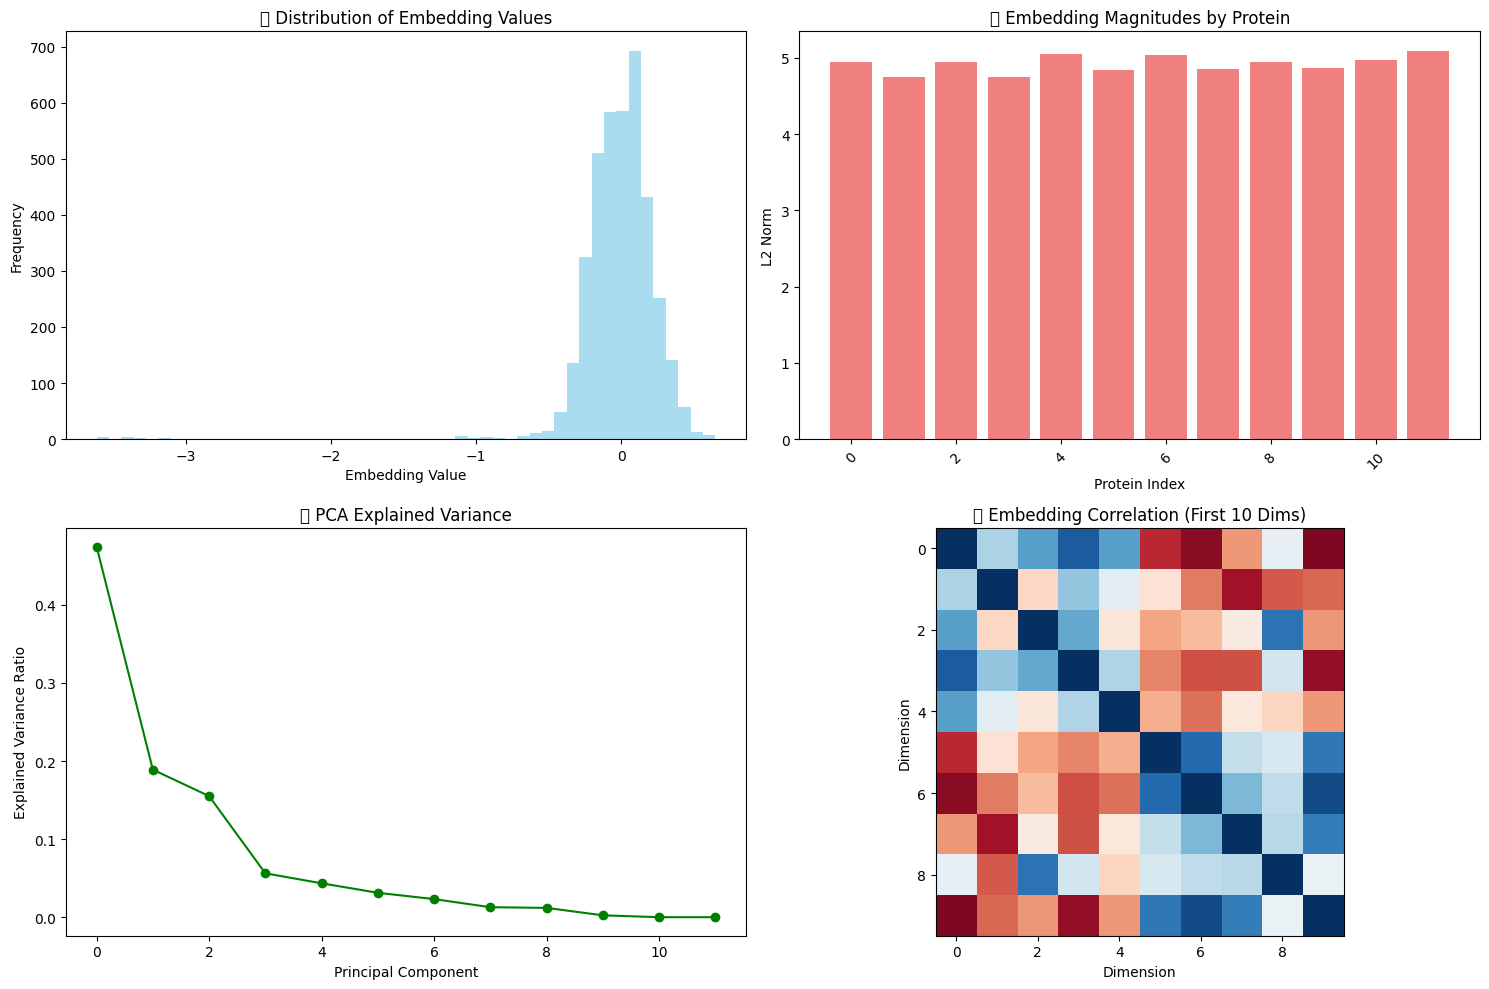

📈 PCA Analysis:
  • First component explains 47.5% of variance
  • First 10 components explain 100.0% of variance


In [6]:
# Cell 3: Embedding statistics and distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution of embedding values
axes[0,0].hist(embedding_matrix.flatten(), bins=50, alpha=0.7, color='skyblue')
axes[0,0].set_title('🔢 Distribution of Embedding Values')
axes[0,0].set_xlabel('Embedding Value')
axes[0,0].set_ylabel('Frequency')

# Embedding norms (magnitude of each protein vector)
norms = np.linalg.norm(embedding_matrix, axis=1)
axes[0,1].bar(range(len(norms)), norms, color='lightcoral')
axes[0,1].set_title('📏 Embedding Magnitudes by Protein')
axes[0,1].set_xlabel('Protein Index')
axes[0,1].set_ylabel('L2 Norm')
axes[0,1].tick_params(axis='x', rotation=45)

# First few principal components
pca = PCA()
pca.fit(embedding_matrix)
axes[1,0].plot(pca.explained_variance_ratio_[:20], 'o-', color='green')
axes[1,0].set_title('📊 PCA Explained Variance')
axes[1,0].set_xlabel('Principal Component')
axes[1,0].set_ylabel('Explained Variance Ratio')

# Correlation heatmap of first 10 dimensions
axes[1,1].imshow(np.corrcoef(embedding_matrix[:, :10].T), cmap='RdBu', vmin=-1, vmax=1)
axes[1,1].set_title('🔥 Embedding Correlation (First 10 Dims)')
axes[1,1].set_xlabel('Dimension')
axes[1,1].set_ylabel('Dimension')

plt.tight_layout()
plt.show()

print(f"📈 PCA Analysis:")
print(f"  • First component explains {pca.explained_variance_ratio_[0]:.1%} of variance")
print(f"  • First 10 components explain {pca.explained_variance_ratio_[:10].sum():.1%} of variance")

In [7]:
# Cell 4: Protein similarity analysis
print("🔍 Protein Similarity Analysis:")
print("="*35)

# Calculate cosine similarity matrix
similarity_matrix = cosine_similarity(embedding_matrix)

# Create interactive heatmap
fig = px.imshow(similarity_matrix, 
                x=protein_ids, y=protein_ids,
                color_continuous_scale='RdYlBu_r',
                title="🔥 Protein Similarity Heatmap (Cosine Similarity)")

fig.update_layout(
    width=800, height=800,
    xaxis_title="Protein",
    yaxis_title="Protein"
)
fig.show()

# Find most similar protein pairs
similarity_pairs = []
for i in range(len(protein_ids)):
    for j in range(i+1, len(protein_ids)):
        similarity_pairs.append({
            'protein1': protein_ids[i],
            'protein2': protein_ids[j], 
            'similarity': similarity_matrix[i, j]
        })

similarity_df = pd.DataFrame(similarity_pairs).sort_values('similarity', ascending=False)

print(f"\n🏆 Most Similar Protein Pairs:")
for _, row in similarity_df.head(5).iterrows():
    print(f"  • {row['protein1']} ↔ {row['protein2']}: {row['similarity']:.3f}")

print(f"\n🔻 Most Different Protein Pairs:")
for _, row in similarity_df.tail(5).iterrows():
    print(f"  • {row['protein1']} ↔ {row['protein2']}: {row['similarity']:.3f}")

🔍 Protein Similarity Analysis:



🏆 Most Similar Protein Pairs:
  • Adalimumab_heavy ↔ Trastuzumab_heavy: 1.000
  • Adalimumab_light ↔ Trastuzumab_light: 0.999
  • Adalimumab_heavy ↔ Bevacizumab_heavy: 0.997
  • Trastuzumab_heavy ↔ Bevacizumab_heavy: 0.997
  • Trastuzumab_light ↔ Bevacizumab_light: 0.994

🔻 Most Different Protein Pairs:
  • Bevacizumab_heavy ↔ Bevacizumab_light: 0.965
  • Adalimumab_light ↔ Bevacizumab_heavy: 0.965
  • Bevacizumab_light ↔ Pembrolizumab_heavy: 0.963
  • Bevacizumab_heavy ↔ Pembrolizumab_light: 0.963
  • Pembrolizumab_heavy ↔ Pembrolizumab_light: 0.947


In [11]:
# Cell 5: Dimensionality reduction visualization
print("🎨 2D Visualization of Embedding Space:")
print("="*40)

# First, let's check what columns we have
print("Available columns in df:", df.columns.tolist())

# Create therapeutic area classification if it doesn't exist
if 'therapeutic_area' not in df.columns:
    print("Creating therapeutic area classification...")
    
    def classify_therapeutic_area(indication):
        """Classify therapeutic area based on indication"""
        indication_lower = indication.lower()
        if 'cancer' in indication_lower or 'melanoma' in indication_lower:
            return 'Oncology'
        elif 'arthritis' in indication_lower or 'crohn' in indication_lower:
            return 'Autoimmune'
        elif 'lymphoma' in indication_lower:
            return 'Hematology'
        else:
            return 'Other'
    
    df['therapeutic_area'] = df['indication'].apply(classify_therapeutic_area)
    print("✅ Therapeutic areas created")

# PCA for 2D visualization
pca_2d = PCA(n_components=2)
embeddings_pca = pca_2d.fit_transform(embedding_matrix)

# t-SNE for 2D visualization (better for non-linear patterns)
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(protein_ids)-1))
embeddings_tsne = tsne.fit_transform(embedding_matrix)

# Create visualization dataframe
viz_df = pd.DataFrame({
    'protein_id': protein_ids,
    'pca_x': embeddings_pca[:, 0],
    'pca_y': embeddings_pca[:, 1], 
    'tsne_x': embeddings_tsne[:, 0],
    'tsne_y': embeddings_tsne[:, 1]
})

# Add metadata
viz_df['drug_name'] = viz_df['protein_id'].str.split('_').str[0]
viz_df['chain_type'] = viz_df['protein_id'].str.split('_').str[1]

# Merge with therapeutic area info
drug_therapy = df.groupby('name')['therapeutic_area'].first().to_dict()
viz_df['therapeutic_area'] = viz_df['drug_name'].map(drug_therapy)

# Import plotly subplots
from plotly.subplots import make_subplots

# Create subplots
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['PCA Projection', 't-SNE Projection'],
    specs=[[{"secondary_y": False}, {"secondary_y": False}]]
)

# PCA plot
for area in viz_df['therapeutic_area'].unique():
    if pd.notna(area):  # Skip NaN values
        area_data = viz_df[viz_df['therapeutic_area'] == area]
        fig.add_trace(
            go.Scatter(x=area_data['pca_x'], y=area_data['pca_y'],
                      mode='markers+text',
                      text=area_data['protein_id'],
                      textposition="top center",
                      name=f'{area} (PCA)',
                      marker=dict(size=10)),
            row=1, col=1
        )

# t-SNE plot  
for area in viz_df['therapeutic_area'].unique():
    if pd.notna(area):  # Skip NaN values
        area_data = viz_df[viz_df['therapeutic_area'] == area]
        fig.add_trace(
            go.Scatter(x=area_data['tsne_x'], y=area_data['tsne_y'],
                      mode='markers+text', 
                      text=area_data['protein_id'],
                      textposition="top center",
                      name=f'{area} (t-SNE)',
                      marker=dict(size=10)),
            row=1, col=2
        )

fig.update_layout(height=600, title_text="🎨 Protein Embedding Space Visualization")
fig.show()

print(f"📊 Variance explained by PCA:")
print(f"  • PC1: {pca_2d.explained_variance_ratio_[0]:.1%}")
print(f"  • PC2: {pca_2d.explained_variance_ratio_[1]:.1%}")
print(f"  • Total: {pca_2d.explained_variance_ratio_.sum():.1%}")

# Show the therapeutic area breakdown
print(f"\n🎯 Therapeutic Areas in Dataset:")
area_counts = viz_df['therapeutic_area'].value_counts()
for area, count in area_counts.items():
    print(f"  • {area}: {count} protein chains")

🎨 2D Visualization of Embedding Space:
Available columns in df: ['name', 'brand_name', 'drugbank_id', 'indication', 'approval_year', 'company', 'chain_type', 'sequence', 'sequence_length', 'molecular_type']
Creating therapeutic area classification...
✅ Therapeutic areas created


📊 Variance explained by PCA:
  • PC1: 47.5%
  • PC2: 18.9%
  • Total: 66.4%

🎯 Therapeutic Areas in Dataset:
  • Oncology: 7 protein chains
  • Autoimmune: 3 protein chains
  • Hematology: 2 protein chains


🔗 Heavy vs Light Chain Analysis:
Heavy chains: 7
Light chains: 5

🔍 Heavy vs Light chain similarity: 0.981


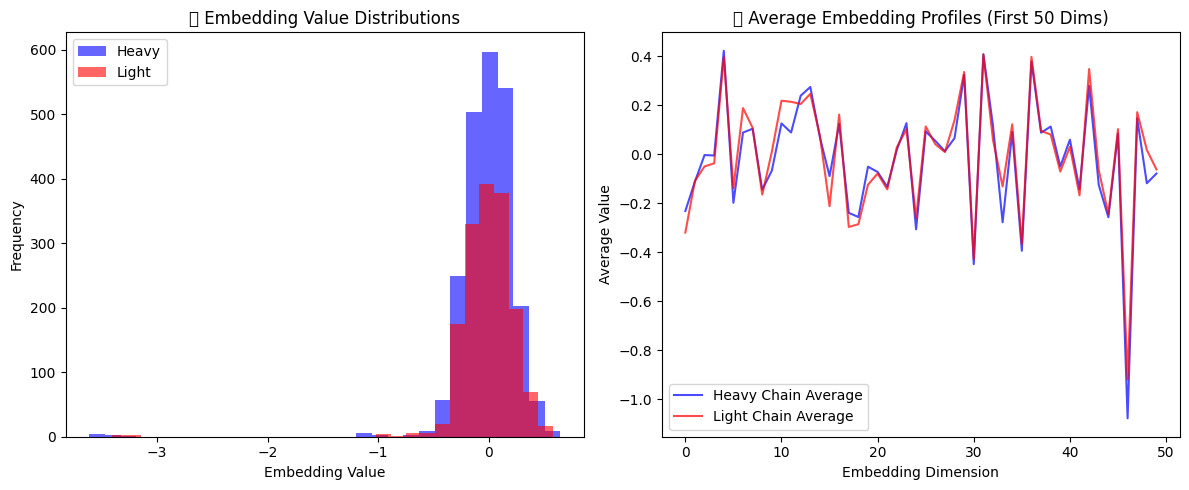

In [9]:
# Cell 6: Chain type analysis
print("🔗 Heavy vs Light Chain Analysis:")
print("="*35)

# Separate heavy and light chains
heavy_chains = [pid for pid in protein_ids if 'heavy' in pid]
light_chains = [pid for pid in protein_ids if 'light' in pid]

heavy_embeddings = np.array([embeddings[pid] for pid in heavy_chains])
light_embeddings = np.array([embeddings[pid] for pid in light_chains])

print(f"Heavy chains: {len(heavy_chains)}")
print(f"Light chains: {len(light_chains)}")

# Compare average embeddings
if len(heavy_chains) > 0 and len(light_chains) > 0:
    heavy_mean = heavy_embeddings.mean(axis=0)
    light_mean = light_embeddings.mean(axis=0)
    
    chain_similarity = cosine_similarity([heavy_mean], [light_mean])[0, 0]
    print(f"\n🔍 Heavy vs Light chain similarity: {chain_similarity:.3f}")
    
    # Plot comparison
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(heavy_embeddings.flatten(), bins=30, alpha=0.6, label='Heavy', color='blue')
    plt.hist(light_embeddings.flatten(), bins=30, alpha=0.6, label='Light', color='red')
    plt.xlabel('Embedding Value')
    plt.ylabel('Frequency')
    plt.title('🔢 Embedding Value Distributions')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(heavy_mean[:50], 'b-', label='Heavy Chain Average', alpha=0.7)
    plt.plot(light_mean[:50], 'r-', label='Light Chain Average', alpha=0.7)
    plt.xlabel('Embedding Dimension')
    plt.ylabel('Average Value')
    plt.title('📊 Average Embedding Profiles (First 50 Dims)')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [10]:
# Cell 7: Save processed embeddings for next steps
print("💾 Preparing Embeddings for FAISS:")
print("="*35)

# Create final embedding matrix and metadata for FAISS
final_data = {
    'embeddings': embedding_matrix,
    'protein_ids': protein_ids,
    'metadata': viz_df.to_dict('records')
}

# Save for FAISS indexing
with open("../models/embeddings_for_faiss.pkl", "wb") as f:
    pickle.dump(final_data, f)

print(f"✅ Saved embedding matrix: {embedding_matrix.shape}")
print(f"✅ Saved protein IDs: {len(protein_ids)}")
print(f"✅ Ready for FAISS indexing!")

# Summary statistics
print(f"\n📈 Embedding Generation Summary:")
print(f"  • Model: ESM2-8M")
print(f"  • Proteins processed: {len(protein_ids)}")
print(f"  • Embedding dimension: {embedding_matrix.shape[1]}")
print(f"  • Average similarity: {similarity_matrix.mean():.3f}")
print(f"  • Memory footprint: {embedding_matrix.nbytes / 1024**2:.1f} MB")
print(f"  • Status: ✅ Ready for similarity search!")

💾 Preparing Embeddings for FAISS:
✅ Saved embedding matrix: (12, 320)
✅ Saved protein IDs: 12
✅ Ready for FAISS indexing!

📈 Embedding Generation Summary:
  • Model: ESM2-8M
  • Proteins processed: 12
  • Embedding dimension: 320
  • Average similarity: 0.979
  • Memory footprint: 0.0 MB
  • Status: ✅ Ready for similarity search!
